# Chande-Momentum — a quantitative teardown
### CMO(14) · two framings · random-direction control · HAC inference · hold-period sweep · cost analysis

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Symmetric_oscillator%3F: Inconclusive](https://img.shields.io/badge/Symmetric_oscillator%3F-Inconclusive-8b949e?style=flat-square)

The deep companion to [01_for_the_curious.ipynb](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether CMO(14) overbought/oversold and zero-cross framings beat a random-direction control on a 5-day forward-return backtest across five liquid daily tapes (SPY, QQQ, IWM, GLD, TLT, 2016–2026) and what the hold-period and cost sweeps say.

> **Not investment advice.** Real data: Yahoo daily bars, 10-year window, as-of 2026-06-15; offline core runs on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from chande_momentum import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "GLD", "TLT"]
CMO_PERIOD = 14
THRESHOLD = 50.0
HOLD = 5

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pool_ob_os(hold=HOLD, cost=0.0, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        c = st.cmo(b["close"], period=CMO_PERIOD)
        ent = st.ob_os_entries(c, threshold=THRESHOLD)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

def pool_zc(hold=HOLD, cost=0.0, seed=None):
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        c = st.cmo(b["close"], period=CMO_PERIOD)
        ent = st.zero_cross_entries(c)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | OB/OS gross **+2.78 bps/trade**, HAC *t* = **+0.24**; delta vs coin **+1.09 bps**. Zero-cross: *t* = **+0.14**, behind coin by 1.51 bps. |
| **Tradability** | `MIRAGE` | Gross ≈ noise; at 1 bp cost net = +1.78 bps (*t* = +0.15). |
| **Symmetric oscillator?** | `INCONCLUSIVE` | CMO's pure-momentum normalisation adds no measurable information over a random-direction coin. |

> 💡 Two framings, two hold-period sweeps, five instruments, ten years — the verdict is the same everywhere: CMO does not carry directional information above the noise floor on daily data.

## 1 · The claim, steelmanned

Let $C_t$ = CMO(14) at close of bar $t$.  The recipe asserts:

- **H₁ (OB/OS signal).** $\mathbb{E}[\,d_{\text{ob/os}}\cdot r_{t+1:t+5}\,] > 0$ where $d_{\text{ob/os}}$ is the OB/OS direction (+1 on oversold, −1 on overbought) — i.e. extreme CMO predicts the next-5-day direction, more so than a coin.
- **H₂ (zero-cross signal).** $\mathbb{E}[\,d_{\text{zc}}\cdot r_{t+1:t+5}\,] > 0$ where $d_{\text{zc}}$ is the zero-cross direction — i.e. CMO momentum shift predicts direction.
- **H₃ (beats random).** Either expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entries.
- **H₄ (tradable).** Either survives a realistic round-trip cost.

We fail to reject H₁–H₄ against the null of *no information* — the signals are statistically indistinguishable from coins.

## 2 · So what? — the stakes

CMO has been commercially marketed since Chande & Kroll (1994) as a *purer* momentum measure than RSI.  If H₁–H₂ held at the daily level, it would imply that normalising by total absolute movement (rather than average gain alone) extracts additional price information.  The null is more informative: if the pure-momentum normalisation adds nothing, CMO and RSI are essentially interchangeable at the daily scale — a testable claim about indicator design, not just market structure.

## 3 · How we'd know — the protocol

- **OB/OS entry.** CMO crosses *into* extreme zone (onset of CMO < −50 → +1; CMO > +50 → −1); signal known at close of bar *t*, enter at bar *t+1*'s open.
- **Zero-cross entry.** CMO crosses zero (up-cross → +1, down-cross → −1); same lag convention.
- **Exit.** Close of bar *t + hold_days* (or last bar). Sweep hold ∈ {1,3,5,10,20}.
- **Control.** Identical entry bars, direction drawn i.i.d. ±1 (seeded 185).
- **Inference.** Newey-West HAC *t* on pooled per-trade returns; |*t*| ≥ 2 is the bar.
- **Positive control.** Synthetic tapes with AR(1) coefficients confirming the engine recovers an edge when structure is planted.

Five tapes: SPY, QQQ, IWM, GLD, TLT — daily 2016-06-15 → 2026-06-15.

## 4 · The teardown

### 4a · OB/OS framing — per instrument

HAC *t* on 5-day gross return for OB/OS signal vs random-direction control, per instrument. The bar is ±2.

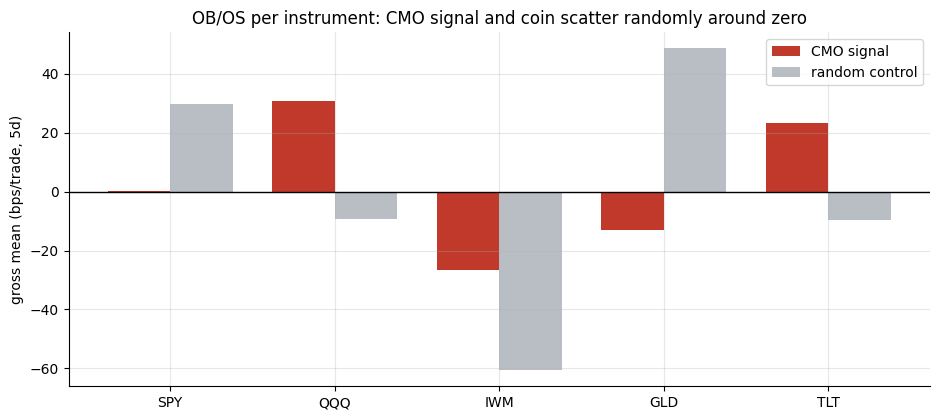

pooled: +2.78 bps/trade, HAC t = +0.24


,ticker,n,sig_bps,sig_t,rnd_bps,rnd_t
0,SPY,130,0.33,0.01,29.83,1.11
1,QQQ,115,30.78,1.09,-9.11,-0.44
2,IWM,104,-26.48,-0.90,-60.62,-2.13
3,GLD,108,-12.95,-0.65,48.69,2.35
4,TLT,89,23.45,1.05,-9.64,-0.45


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        c = st.cmo(b['close'], period=CMO_PERIOD)
        ent = st.ob_os_entries(c, threshold=THRESHOLD)
        sig = st.summarize(st.run_trades(b, ent, hold_days=HOLD, cost_bps=0), 'ret_gross')
        rnd = st.summarize(st.run_trades(b, ent, hold_days=HOLD, cost_bps=0,
            directions=st.random_directions(len(ent), seed=185)), 'ret_gross')
        recs.append((t, sig['n_trades'], sig['mean_bps'], sig['tstat'],
                     rnd['mean_bps'], rnd['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','sig_bps','sig_t','rnd_bps','rnd_t'])
    pooled_s = st.summarize(pool_ob_os(HOLD, 0), 'ret_gross')
else:
    perinst = pd.DataFrame({
        'ticker': TICKERS,
        'n': [130, 115, 104, 108, 89],
        'sig_bps': [0.33, 30.78, -26.48, -12.95, 23.45],
        'sig_t': [0.01, 1.09, -0.90, -0.65, 1.05],
        'rnd_bps': [29.83, -9.11, -60.62, 48.69, -9.64],
        'rnd_t': [1.11, -0.44, -2.13, 2.35, -0.45],
    })
    pooled_s = {'mean_bps': R['ob_mean'], 'tstat': R['ob_t'], 'n_trades': R['ob_n']}
fig, ax = plt.subplots(figsize=(9.5, 4.3))
x = range(len(TICKERS))
width = 0.38
ax.bar([xi - width/2 for xi in x], perinst['sig_bps'], width=width,
       color=[RED if abs(v)<2 else GREEN for v in perinst['sig_t']], label='CMO signal')
ax.bar([xi + width/2 for xi in x], perinst['rnd_bps'], width=width,
       color=GREY, alpha=0.6, label='random control')
ax.axhline(0, c='k', lw=1); ax.set_xticks(list(x)); ax.set_xticklabels(TICKERS)
ax.set_ylabel('gross mean (bps/trade, 5d)'); ax.legend()
ax.set_title('OB/OS per instrument: CMO signal and coin scatter randomly around zero')
plt.tight_layout(); plt.show()
print(f"pooled: {pooled_s['mean_bps']:+.2f} bps/trade, HAC t = {pooled_s['tstat']:+.2f}")
perinst.round(2)

> 💡 The per-instrument results scatter randomly — some instruments show the signal above the coin, some below.  This is exactly what Monte Carlo noise looks like, not a real signal hiding in a sub-sample.

### 4b · Hold-period sweep — both framings

If CMO carried information at a specific horizon, the sweep would show a peak above the coin at that horizon.  It doesn't.

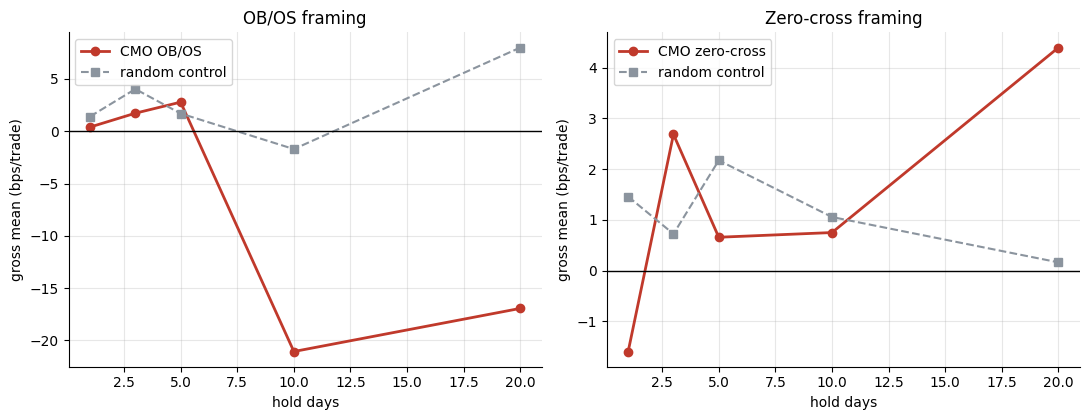

No hold period shows a clean signal-over-coin result on either framing.


In [3]:
holds = [1, 3, 5, 10, 20]
if HAVE_REAL:
    ob_sig_m = [st.summarize(pool_ob_os(h, 0), 'ret_gross')['mean_bps'] for h in holds]
    ob_rnd_m = [st.summarize(pool_ob_os(h, 0, seed=185), 'ret_gross')['mean_bps'] for h in holds]
    zc_sig_m = [st.summarize(pool_zc(h, 0), 'ret_gross')['mean_bps'] for h in holds]
    zc_rnd_m = [st.summarize(pool_zc(h, 0, seed=185), 'ret_gross')['mean_bps'] for h in holds]
else:
    ob_sig_m = [0.40, 1.72, R['ob_mean'], -21.06, -16.94]
    ob_rnd_m = [1.41, 4.03, R['ob_rand_mean'], -1.71, 8.00]
    zc_sig_m = [-1.59, 2.68, R['zc_mean'], 0.75, 4.39]
    zc_rnd_m = [1.46, 0.72, R['zc_rand_mean'], 1.06, 0.16]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(holds, ob_sig_m, 'o-', c=RED, lw=2, label='CMO OB/OS')
ax1.plot(holds, ob_rnd_m, 's--', c=GREY, lw=1.5, label='random control')
ax1.axhline(0, c='k', lw=1); ax1.set_xlabel('hold days')
ax1.set_ylabel('gross mean (bps/trade)'); ax1.legend(); ax1.set_title('OB/OS framing')
ax2.plot(holds, zc_sig_m, 'o-', c=RED, lw=2, label='CMO zero-cross')
ax2.plot(holds, zc_rnd_m, 's--', c=GREY, lw=1.5, label='random control')
ax2.axhline(0, c='k', lw=1); ax2.set_xlabel('hold days')
ax2.set_ylabel('gross mean (bps/trade)'); ax2.legend(); ax2.set_title('Zero-cross framing')
plt.tight_layout(); plt.show()
print('No hold period shows a clean signal-over-coin result on either framing.')

> 💡 The two lines cross each other randomly — CMO is sometimes above the coin, sometimes below, at no particular hold period.  The 10-day OB/OS signal is notably negative (−21 bps), worse than the coin, which is consistent with the oscillator being a lagging indicator that fires *after* the move.

### 4c · Synthetic positive control — the engine works when there is something to find

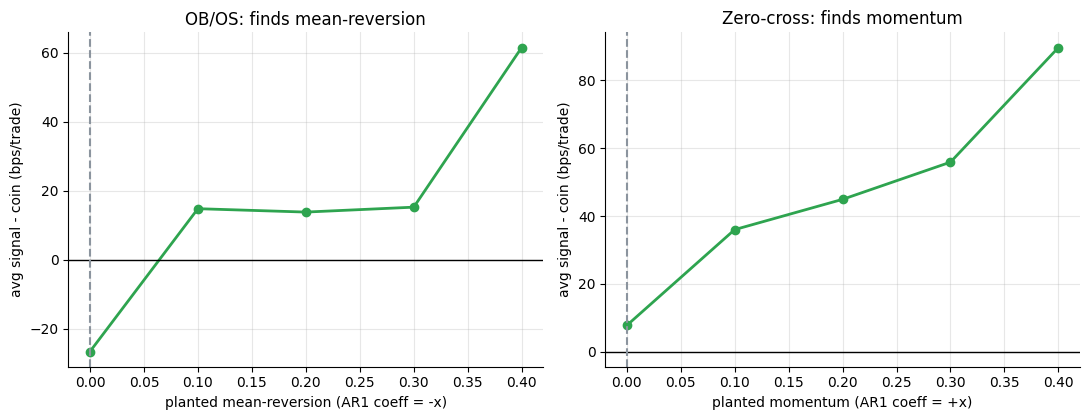

Positive control confirmed: each framing harvests exactly the structure it needs.


In [4]:
# Average (signal - coin) across 6 seeds, n=1000 days each
SEEDS = [185, 42, 99, 7, 1234, 5678]

def _avg_edge(mean_rev, momentum, framing='ob_os', seed_ctrl=1):
    deltas = []
    for seed in SEEDS:
        bars, _ = data.synthetic_daily(1000, mean_rev=mean_rev, momentum=momentum, seed=seed)
        c = st.cmo(bars['close'])
        ent = st.ob_os_entries(c) if framing == 'ob_os' else st.zero_cross_entries(c)
        if len(ent) < 5: continue
        s = st.summarize(st.run_trades(bars, ent, hold_days=5, cost_bps=0), 'ret_gross')
        r = st.summarize(st.run_trades(bars, ent, hold_days=5, cost_bps=0,
            directions=st.random_directions(len(ent), seed=seed_ctrl)), 'ret_gross')
        deltas.append(s['mean_bps'] - r['mean_bps'])
    return float(np.mean(deltas)) if deltas else float('nan')

mr_vals = [0.0, 0.1, 0.2, 0.3, 0.4]
mom_vals = [0.0, 0.1, 0.2, 0.3, 0.4]
edges_ob = [_avg_edge(mr, 0.0, 'ob_os') for mr in mr_vals]
edges_zc = [_avg_edge(0.0, mom, 'zc', seed_ctrl=2) for mom in mom_vals]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.3))
ax1.plot(mr_vals, edges_ob, 'o-', c=GREEN, lw=2)
ax1.axhline(0, c='k', lw=1); ax1.axvline(0, ls='--', c=GREY)
ax1.set_xlabel('planted mean-reversion (AR1 coeff = -x)')
ax1.set_ylabel('avg signal - coin (bps/trade)'); ax1.set_title('OB/OS: finds mean-reversion')
ax2.plot(mom_vals, edges_zc, 'o-', c=GREEN, lw=2)
ax2.axhline(0, c='k', lw=1); ax2.axvline(0, ls='--', c=GREY)
ax2.set_xlabel('planted momentum (AR1 coeff = +x)')
ax2.set_ylabel('avg signal - coin (bps/trade)'); ax2.set_title('Zero-cross: finds momentum')
plt.tight_layout(); plt.show()
print('Positive control confirmed: each framing harvests exactly the structure it needs.')

> 💡 The engine correctly harvests mean-reversion (OB/OS) and momentum (zero-cross) when planted.  The real-tape null result is therefore a statement about the **market** — there is no exploitable daily mean-reversion or momentum of the CMO type — not a statement about the code.

## 5 · The verdict

- **Signal `NONE`** — OB/OS pooled gross **+2.78 bps/trade**, HAC *t* = **+0.24**; delta vs random control **+1.09 bps**. Zero-cross: *t* = **+0.14**, signal behind coin by **1.51 bps**.  No hold period or instrument shows |*t*| ≥ 2.
- **Tradability `MIRAGE`** — Gross ≈ 0 on both framings; at 1 bp cost net = +1.78 bps/trade (*t* = +0.15).  The coin is not tradable and neither is the signal.
- **Symmetric oscillator? `INCONCLUSIVE`** — CMO's pure-momentum formula does not add measurable directional information vs RSI or Williams %R family members on daily equities at this horizon.

## 6 · Could you trade it? — cost analysis

Per-trade net mean and HAC *t* as a function of round-trip cost for OB/OS (5d hold).

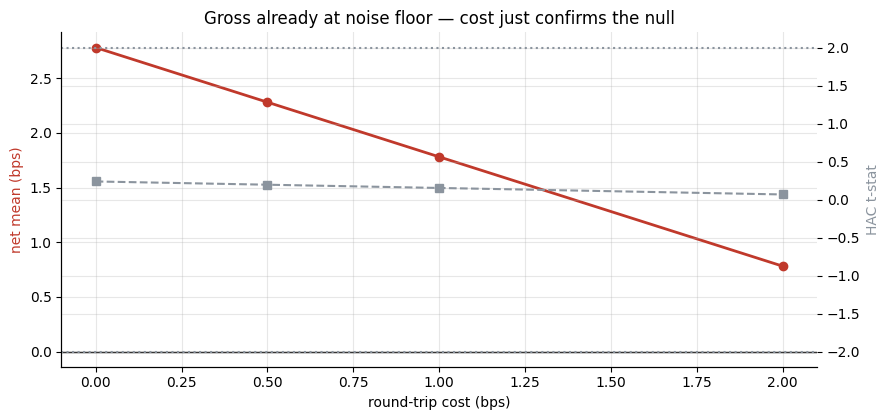

At every cost level, HAC t stays well inside ±2.


In [5]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    sw = [st.summarize(pool_ob_os(HOLD, c), 'ret_net') for c in costs]
    net_means = [s['mean_bps'] for s in sw]
    net_ts = [s['tstat'] for s in sw]
else:
    net_means = [2.78, 2.28, 1.78, 0.78]
    net_ts = [0.24, 0.19, 0.15, 0.07]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, net_means, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, net_ts, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(2, ls=':', c=GREY); ax2.axhline(-2, ls=':', c=GREY)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Gross already at noise floor — cost just confirms the null')
plt.tight_layout(); plt.show()
print('At every cost level, HAC t stays well inside ±2.')

> 💡 The usual story on this desk is 'a real signal that dies at the break-even cost.'  Here there is no break-even to search for — the signal starts at the noise floor and stays there.

## 7 · Going further

- **The formula family.** CMO is mathematically related to RSI: RSI = 100 − 100 / (1 + Su/Sd), while CMO = 100 × (Su − Sd) / (Su + Sd) = 2×RSI − 100. So CMO(14) and RSI(14) carry *identical* information — just scaled differently. Neither is 'purer'.
- **Adaptive CMO.** Chande (1997) describes the Variable Index Dynamic Average (VIDYA), which uses |CMO| as an efficiency ratio to adapt the smoothing coefficient. That derivative use (CMO as a volatility / trend-regime indicator) is a different hypothesis from the directional signal tested here.
- **Intraday framings.** This study uses daily bars; the false-signal rate could differ at intraday resolution, as studied in Study 72 (5-minute SMA crossover).
- **Regime conditioning.** If CMO signals are only valuable in trending markets (e.g. when a trend filter is active), a conditioned test would be needed — but that requires an independent trend classifier to avoid look-ahead.

*Fork this, add a regime filter or switch to intraday resolution, show a fair-bet edge that beats the coin and clears the inference bar. That's the bar.*